<a href="https://colab.research.google.com/github/sarkriti/CSCE-676-Semester-Project/blob/main/DataMiningProject_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project - Updated for Engineered Gender Disparity Dataset

This notebook version uses `gender_disparity_dataset.csv`, which is already cleaned and engineered at the disease-county-year level. It removes the old sex-level pivoting steps and updates the anomaly detection workflow to use the new disparity-focused features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Load engineered dataset

The engineered dataset already contains male/female case and rate features, so there is no need to rebuild them from the original row-level file.

In [ ]:
csv_file_path = 'gender_disparity_dataset.csv'
df = pd.read_csv(csv_file_path)
print(f'Loaded engineered disparity dataset from {csv_file_path}')
print(f'Shape: {df.shape}')
display(df.head())

Loaded engineered disparity dataset from gender_disparity_dataset.csv
Shape: (65250, 21)


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population
0,Anaplasmosis,Alameda,2001,0.0,0.0,746596.0,718968.0,0.0,0.0,0.0,1465564.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.197751
1,Anaplasmosis,Alameda,2002,0.0,0.0,747987.0,720481.0,0.0,0.0,0.0,1468468.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.199731
2,Anaplasmosis,Alameda,2003,0.0,0.0,747441.0,719746.0,0.0,0.0,0.0,1467187.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.198858
3,Anaplasmosis,Alameda,2004,0.0,0.0,746723.0,718817.0,0.0,0.0,0.0,1465540.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.197735
4,Anaplasmosis,Alameda,2005,0.0,0.0,743878.0,716004.0,0.0,0.0,0.0,1459882.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.193867


## Select modeling subset and features

Rows where both sexes have zero cases are excluded because they usually carry no disparity signal for anomaly detection.

In [ ]:
identifier_cols = ['disease', 'county', 'year']

features = [
    'male_rate',
    'female_rate',
    'rate_diff',
    'abs_rate_diff',
    'log_rate_ratio',
    'log_total_cases',
    'log_total_population',
]

df_model = df[df['both_zero_cases'] == 0].copy()
X = df_model[features].apply(pd.to_numeric, errors='coerce')
X_cleaned = X.dropna().copy()

print(f'Rows in full engineered dataset: {len(df)}')
print(f'Rows after removing both_zero_cases == 1: {len(df_model)}')
print(f'Rows after dropping NaNs in selected features: {len(X_cleaned)}')
print('Selected features:', features)
display(X_cleaned.head())

Rows in full engineered dataset: 65250
Rows after removing both_zero_cases == 1: 13495
Rows after dropping NaNs in selected features: 13495
Selected features: ['male_rate', 'female_rate', 'rate_diff', 'abs_rate_diff', 'log_rate_ratio', 'log_total_cases', 'log_total_population']


,male_rate,female_rate,rate_diff,abs_rate_diff,log_rate_ratio,log_total_cases,log_total_population
15,0.000000,0.120211,-0.120211,0.120211,-11.697010,0.693147,14.309577
16,0.122943,0.000000,0.122943,0.122943,11.719481,0.693147,14.316742
18,0.121565,0.000000,0.121565,0.121565,11.708212,0.693147,14.327715
20,0.000000,0.117469,-0.117469,0.117469,-11.673936,0.693147,14.333313
90,0.000000,0.880770,-0.880770,0.880770,-13.688553,0.693147,12.335947


## Isolation Forest

This version runs Isolation Forest directly on `X_cleaned` without creating `X_scaled`.

In [ ]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=0
)

anomaly_predictions = iso.fit_predict(X_cleaned)

df_model['anomaly_iforest'] = 0
df_model.loc[X_cleaned.index, 'anomaly_iforest'] = anomaly_predictions

df_model['anomaly_score_iforest'] = np.nan
df_model.loc[X_cleaned.index, 'anomaly_score_iforest'] = -iso.score_samples(X_cleaned)

print(f'Number of rows processed by IsolationForest: {len(X_cleaned)}')
print(f'Number of anomalies detected: {np.sum(df_model['anomaly_iforest'] == -1)}')
display(df_model[df_model['anomaly_iforest'] == -1].head())

Number of rows processed by IsolationForest: 13495
Number of anomalies detected: 135


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest
9728,Campylobacteriosis,Lake,2023,20.0,13.0,32037.0,32086.0,62.428,40.516,33.0,64123.0,-21.912,21.912,0.649004,-0.432317,0,0,0,0,3.526361,11.068574,-1,0.693116
9775,Campylobacteriosis,Madera,2001,19.0,31.0,65826.0,60630.0,28.864,51.130,50.0,126456.0,22.266,22.266,1.771411,0.571776,0,0,0,0,3.931826,11.747658,-1,0.668255
9862,Campylobacteriosis,Mendocino,2019,20.0,26.0,43848.0,44277.0,45.612,58.721,46.0,88125.0,13.109,13.109,1.287402,0.252627,0,0,0,0,3.850148,11.386523,-1,0.665546
9863,Campylobacteriosis,Mendocino,2020,36.0,15.0,43579.0,43912.0,82.609,34.159,51.0,87491.0,-48.450,48.450,0.413502,-0.883093,0,0,0,0,3.951244,11.379303,-1,0.723674
9866,Campylobacteriosis,Mendocino,2023,36.0,24.0,44134.0,44329.0,81.570,54.141,60.0,88463.0,-27.429,27.429,0.663737,-0.409870,0,0,0,0,4.110874,11.390351,-1,0.726617


## Top Isolation Forest anomalies

Sort flagged rows by anomaly score to inspect the most unusual male/female disparity patterns first.

In [ ]:
anomalies_iforest = df_model[df_model['anomaly_iforest'] == -1].copy()
anomalies_iforest = anomalies_iforest.sort_values('anomaly_score_iforest', ascending=False)

display(
    anomalies_iforest[
        identifier_cols + [
            'male_cases', 'female_cases',
            'male_rate', 'female_rate',
            'rate_diff', 'abs_rate_diff', 'rate_ratio',
            'total_cases', 'total_county_population',
            'anomaly_iforest', 'anomaly_score_iforest'
        ]
    ].head(20)
)

,disease,county,year,male_cases,female_cases,male_rate,female_rate,rate_diff,abs_rate_diff,rate_ratio,total_cases,total_county_population,anomaly_iforest,anomaly_score_iforest
14142,Coccidioidomycosis,Kern,2017,1660.0,1134.0,361.52,261.430,100.090,100.090,1.382856,2794.0,892933.0,-1,0.816694
14136,Coccidioidomycosis,Kern,2011,1507.0,1051.0,343.75,254.860,88.890,88.890,1.348780,2558.0,850777.0,-1,0.815224
14137,Coccidioidomycosis,Kern,2012,1142.0,691.0,258.75,165.200,93.550,93.550,1.566283,1833.0,859630.0,-1,0.814762
14143,Coccidioidomycosis,Kern,2018,1684.0,1265.0,364.04,288.280,75.760,75.760,1.262800,2949.0,901403.0,-1,0.813020
14144,Coccidioidomycosis,Kern,2019,1911.0,1474.0,409.38,332.810,76.570,76.570,1.230071,3385.0,909697.0,-1,0.813020
14158,Coccidioidomycosis,Kings,2010,305.0,81.0,353.24,121.550,231.690,231.690,2.906129,386.0,152982.0,-1,0.812076
14141,Coccidioidomycosis,Kern,2016,1330.0,927.0,292.62,215.530,77.090,77.090,1.357676,2257.0,884612.0,-1,0.811372
14135,Coccidioidomycosis,Kern,2010,1138.0,772.0,262.75,189.900,72.850,72.850,1.383623,1910.0,839631.0,-1,0.810823
14159,Coccidioidomycosis,Kings,2011,318.0,57.0,374.31,85.400,288.910,288.910,4.383021,375.0,151701.0,-1,0.809060
14165,Coccidioidomycosis,Kings,2017,212.0,61.0,257.95,89.558,168.392,168.392,2.880256,273.0,150300.0,-1,0.804965


## Isolation Forest tuning

This cell explores how different parameter settings change the number of detected anomalies.

In [ ]:
param_grid_iforest = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.1, 0.25, 0.5, 'auto'],
    'contamination': [0.005, 0.01, 0.02, 0.05],
}

results_iforest_tuning = []

print('Starting Isolation Forest parameter tuning...')
for n_est, max_samp, contam in product(
    param_grid_iforest['n_estimators'],
    param_grid_iforest['max_samples'],
    param_grid_iforest['contamination'],
):
    iso_tuning = IsolationForest(
        n_estimators=n_est,
        max_samples=max_samp,
        contamination=contam,
        random_state=0,
        n_jobs=-1
    )
    preds = iso_tuning.fit_predict(X_cleaned)
    num_anomalies = np.sum(preds == -1)
    results_iforest_tuning.append({
        'n_estimators': n_est,
        'max_samples': max_samp,
        'contamination': contam,
        'num_anomalies': num_anomalies
    })

results_df_iforest = pd.DataFrame(results_iforest_tuning)
display(results_df_iforest.sort_values('num_anomalies', ascending=False).head(10))

Starting Isolation Forest parameter tuning...


,n_estimators,max_samples,contamination,num_anomalies
3,100,0.1,0.05,675
7,100,0.25,0.05,675
15,100,auto,0.05,675
11,100,0.5,0.05,675
27,200,0.5,0.05,675
31,200,auto,0.05,675
23,200,0.25,0.05,675
19,200,0.1,0.05,675
35,300,0.1,0.05,675
39,300,0.25,0.05,675


## Local Outlier Factor

LOF is also run directly on `X_cleaned` for consistency with the updated dataset workflow.

In [ ]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=False
)

anomaly_predictions_lof = lof.fit_predict(X_cleaned)

df_model['anomaly_lof'] = 0
df_model.loc[X_cleaned.index, 'anomaly_lof'] = anomaly_predictions_lof

print(f'Number of rows processed by LOF: {len(X_cleaned)}')
print(f'Number of anomalies detected by LOF: {np.sum(df_model['anomaly_lof'] == -1)}')
display(df_model[df_model['anomaly_lof'] == -1].head())

Number of rows processed by LOF: 13495
Number of anomalies detected by LOF: 134


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof
7424,"Botulism, Wound",Riverside,2019,0.0,2.0,1218203.0,1210261.0,0.000,0.165254,2.0,2428464.0,0.165254,0.165254,NaN,12.015243,0,1,0,1,1.098612,14.702770,1,0.418006,-1
7425,"Botulism, Wound",Riverside,2020,0.0,2.0,1229099.0,1220200.0,0.000,0.163908,2.0,2449299.0,0.163908,0.163908,NaN,12.007064,0,1,0,1,1.098612,14.711313,1,0.418006,-1
9171,Brucellosis,Sutter,2018,0.0,1.0,50535.0,50324.0,0.000,1.987123,1.0,100859.0,1.987123,1.987123,NaN,14.502199,0,1,0,1,0.693147,11.521489,1,0.525942,-1
9728,Campylobacteriosis,Lake,2023,20.0,13.0,32037.0,32086.0,62.428,40.516000,33.0,64123.0,-21.912000,21.912000,0.649004,-0.432317,0,0,0,0,3.526361,11.068574,-1,0.693116,-1
9863,Campylobacteriosis,Mendocino,2020,36.0,15.0,43579.0,43912.0,82.609,34.159000,51.0,87491.0,-48.450000,48.450000,0.413502,-0.883093,0,0,0,0,3.951244,11.379303,-1,0.723674,-1


## Tune LOF n_neighbors

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


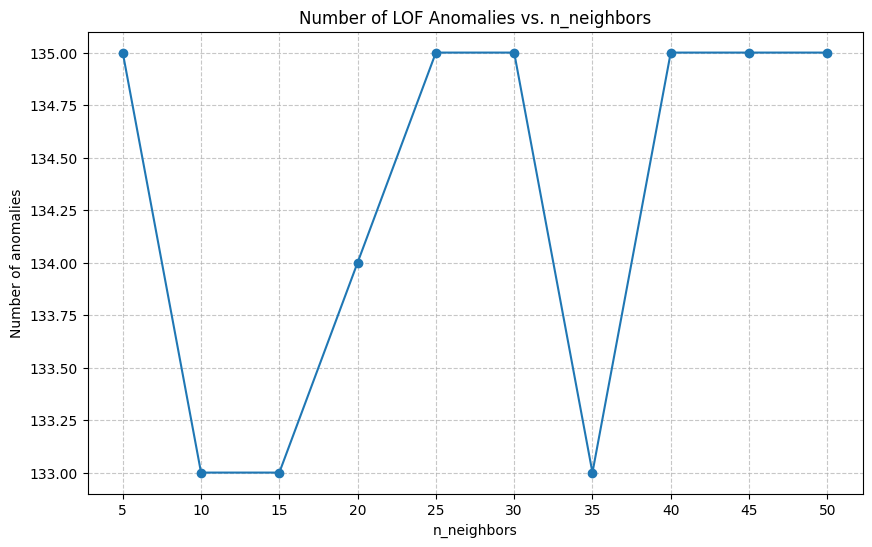

In [ ]:
n_neighbors_values_lof = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
results_lof = {}
contamination_lof = 0.01

for n_neighbors_lof in n_neighbors_values_lof:
    lof_tuning = LocalOutlierFactor(
        n_neighbors=n_neighbors_lof,
        contamination=contamination_lof,
        novelty=False
    )
    preds = lof_tuning.fit_predict(X_cleaned)
    results_lof[n_neighbors_lof] = np.sum(preds == -1)

plt.figure(figsize=(10, 6))
plt.plot(list(results_lof.keys()), list(results_lof.values()), marker='o')
plt.title('Number of LOF Anomalies vs. n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Number of anomalies')
plt.xticks(n_neighbors_values_lof)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## KNN-style anomaly detection

In [ ]:
n_neighbors_knn = 10
nbrs = NearestNeighbors(n_neighbors=n_neighbors_knn)
nbrs.fit(X_cleaned)
distances, indices = nbrs.kneighbors(X_cleaned)

anomaly_scores_knn = distances.mean(axis=1)
contamination_knn = 0.01
threshold_score = np.percentile(anomaly_scores_knn, 100 - contamination_knn * 100)
anomaly_predictions_knn = np.where(anomaly_scores_knn >= threshold_score, -1, 1)

df_model['anomaly_knn'] = 0
df_model.loc[X_cleaned.index, 'anomaly_knn'] = anomaly_predictions_knn
df_model['anomaly_score_knn'] = np.nan
df_model.loc[X_cleaned.index, 'anomaly_score_knn'] = anomaly_scores_knn

print(f'Number of rows processed by KNN-style detector: {len(X_cleaned)}')
print(f'Number of anomalies detected by KNN-style detector: {np.sum(df_model['anomaly_knn'] == -1)}')
display(df_model[df_model['anomaly_knn'] == -1].head())

Number of rows processed by KNN-style detector: 13495
Number of anomalies detected by KNN-style detector: 135


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn
9424,Campylobacteriosis,Butte,2018,53.0,41.0,113297.0,113143.0,46.780,36.237,94.0,226440.0,-10.543,10.543,0.774626,-0.255375,0,0,0,0,4.553877,12.330240,1,0.621203,1,-1,6.299530
9429,Campylobacteriosis,Butte,2023,51.0,34.0,113880.0,114743.0,44.784,29.631,85.0,228623.0,-15.153,15.153,0.661643,-0.413030,0,0,0,0,4.454347,12.339834,1,0.635124,1,-1,8.985858
9632,Campylobacteriosis,Imperial,2019,45.0,38.0,93001.0,95961.0,48.387,39.599,83.0,188962.0,-8.788,8.788,0.818381,-0.200427,0,0,0,0,4.430817,12.149307,1,0.625829,1,-1,7.428958
9633,Campylobacteriosis,Imperial,2020,46.0,44.0,92594.0,95496.0,49.679,46.075,90.0,188090.0,-3.604,3.604,0.927454,-0.075312,0,0,0,0,4.510860,12.144681,1,0.605877,1,-1,5.731202
9635,Campylobacteriosis,Imperial,2022,61.0,63.0,94987.0,97973.0,64.219,64.303,124.0,192960.0,0.084,0.084,1.001308,0.001307,0,0,0,0,4.828314,12.170243,1,0.624721,1,-1,13.735367


## Compare overlap across methods

In [ ]:
df_model['anomaly_both_if_lof'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] == -1)).astype(int)
df_model['anomaly_both_if_knn'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)
df_model['anomaly_both_lof_knn'] = ((df_model['anomaly_lof'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)
df_model['anomaly_all_three'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)

df_model['anomaly_iforest_only'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] != -1) & (df_model['anomaly_knn'] != -1)).astype(int)
df_model['anomaly_lof_only'] = ((df_model['anomaly_lof'] == -1) & (df_model['anomaly_iforest'] != -1) & (df_model['anomaly_knn'] != -1)).astype(int)
df_model['anomaly_knn_only'] = ((df_model['anomaly_knn'] == -1) & (df_model['anomaly_iforest'] != -1) & (df_model['anomaly_lof'] != -1)).astype(int)

print(f"Total anomalies detected by Isolation Forest: {np.sum(df_model['anomaly_iforest'] == -1)}")
print(f"Total anomalies detected by LOF: {np.sum(df_model['anomaly_lof'] == -1)}")
print(f"Total anomalies detected by KNN: {np.sum(df_model['anomaly_knn'] == -1)}")
print(f"Anomalies detected by BOTH IF and LOF: {df_model['anomaly_both_if_lof'].sum()}")
print(f"Anomalies detected by BOTH IF and KNN: {df_model['anomaly_both_if_knn'].sum()}")
print(f"Anomalies detected by BOTH LOF and KNN: {df_model['anomaly_both_lof_knn'].sum()}")
print(f"Anomalies detected by ALL THREE methods: {df_model['anomaly_all_three'].sum()}")

Total anomalies detected by Isolation Forest: 135
Total anomalies detected by LOF: 134
Total anomalies detected by KNN: 135
Anomalies detected by BOTH IF and LOF: 7
Anomalies detected by BOTH IF and KNN: 113
Anomalies detected by BOTH LOF and KNN: 9
Anomalies detected by ALL THREE methods: 7


## Export anomaly CSVs

In [ ]:
export_columns = [
    'disease', 'county', 'year',
    'male_cases', 'female_cases',
    'male_population', 'female_population',
    'male_rate', 'female_rate',
    'rate_diff', 'abs_rate_diff', 'rate_ratio',
    'total_cases', 'total_county_population',
    'anomaly_iforest', 'anomaly_lof', 'anomaly_knn',
    'anomaly_score_iforest', 'anomaly_score_knn'
]

if (df_model['anomaly_iforest'] == -1).sum() > 0:
    df_model[df_model['anomaly_iforest'] == -1][export_columns].to_csv('anomalies_iforest_all.csv', index=False)
    print('Exported anomalies_iforest_all.csv')

if (df_model['anomaly_lof'] == -1).sum() > 0:
    df_model[df_model['anomaly_lof'] == -1][export_columns].to_csv('anomalies_lof_all.csv', index=False)
    print('Exported anomalies_lof_all.csv')

if (df_model['anomaly_knn'] == -1).sum() > 0:
    df_model[df_model['anomaly_knn'] == -1][export_columns].to_csv('anomalies_knn_all.csv', index=False)
    print('Exported anomalies_knn_all.csv')

if df_model['anomaly_both_if_lof'].sum() > 0:
    df_model[df_model['anomaly_both_if_lof'] == 1][export_columns].to_csv('anomalies_iforest_lof_overlap.csv', index=False)
    print('Exported anomalies_iforest_lof_overlap.csv')

if df_model['anomaly_both_if_knn'].sum() > 0:
    df_model[df_model['anomaly_both_if_knn'] == 1][export_columns].to_csv('anomalies_iforest_knn_overlap.csv', index=False)
    print('Exported anomalies_iforest_knn_overlap.csv')

if df_model['anomaly_both_lof_knn'].sum() > 0:
    df_model[df_model['anomaly_both_lof_knn'] == 1][export_columns].to_csv('anomalies_lof_knn_overlap.csv', index=False)
    print('Exported anomalies_lof_knn_overlap.csv')

Exported anomalies_iforest_all.csv
Exported anomalies_lof_all.csv
Exported anomalies_knn_all.csv
Exported anomalies_iforest_lof_overlap.csv
Exported anomalies_iforest_knn_overlap.csv
Exported anomalies_lof_knn_overlap.csv


In [ ]:
def get_top_diseases_df(df, anomaly_col, method_name, top_n=3):
    if anomaly_col in ['anomaly_both_if_lof', 'anomaly_both_if_knn', 'anomaly_both_lof_knn', 'anomaly_all_three']:
        anomalies = df[df[anomaly_col] == 1]
    else:
        anomalies = df[df[anomaly_col] == -1]

    if not anomalies.empty:
        top_diseases = anomalies['disease'].value_counts().head(top_n).reset_index()
        top_diseases.columns = ['Disease', 'Count']
        top_diseases['Method'] = method_name
        return top_diseases
    else:
        return pd.DataFrame(columns=['Disease', 'Count', 'Method'])


all_top_diseases = pd.concat([
    get_top_diseases_df(df_model, 'anomaly_iforest', 'Isolation Forest'),
    get_top_diseases_df(df_model, 'anomaly_lof', 'LOF'),
    get_top_diseases_df(df_model, 'anomaly_knn', 'KNN'),
    get_top_diseases_df(df_model, 'anomaly_both_if_lof', 'IF & LOF Overlap'),
    get_top_diseases_df(df_model, 'anomaly_both_if_knn', 'IF & KNN Overlap'),
    get_top_diseases_df(df_model, 'anomaly_both_lof_knn', 'LOF & KNN Overlap'),
    get_top_diseases_df(df_model, 'anomaly_all_three', 'All Three Overlap'),
])

display(all_top_diseases)

,Disease,Count,Method
0,Coccidioidomycosis,96,Isolation Forest
1,Campylobacteriosis,21,Isolation Forest
2,Giardiasis,9,Isolation Forest
0,Shiga toxin-producing E. coli (STEC) without HUS,11,LOF
1,Cryptosporidiosis,10,LOF
2,Hemolytic Uremic Syndrome,10,LOF
0,Coccidioidomycosis,88,KNN
1,Campylobacteriosis,32,KNN
2,Giardiasis,5,KNN
0,Campylobacteriosis,3,IF & LOF Overlap


In [ ]:
cocci_lof_anomalies = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_lof'] == -1)]
print(f"Number of Coccidioidomycosis cases detected by LOF: {len(cocci_lof_anomalies)}")

Number of Coccidioidomycosis cases detected by LOF: 7


## Coccidioidomycosis Anomalies by Detection Method

In [ ]:
cocci_anomalies_iforest = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_iforest'] == -1)]
print(f"Coccidioidomycosis anomalies by Isolation Forest ({len(cocci_anomalies_iforest)} cases):")
display(cocci_anomalies_iforest.head())

Coccidioidomycosis anomalies by Isolation Forest (96 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14015,Coccidioidomycosis,Fresno,2005,33.0,298.0,436052.0,435858.0,7.568,68.371,331.0,871910.0,60.803,60.803,9.034223,2.201020,0,0,0,0,5.805135,13.678443,-1,0.744396,1,-1,17.753921,0,1,0,0,0,0,0
14016,Coccidioidomycosis,Fresno,2006,39.0,626.0,443403.0,442973.0,8.796,141.320,665.0,886376.0,132.524,132.524,16.066394,2.776730,0,0,0,0,6.501290,13.694898,-1,0.776512,1,-1,63.677893,0,1,0,0,0,0,0
14017,Coccidioidomycosis,Fresno,2007,37.0,363.0,450080.0,449746.0,8.221,80.712,400.0,899826.0,72.491,72.491,9.817784,2.284195,0,0,0,0,5.993961,13.709958,-1,0.751480,1,-1,27.666899,0,1,0,0,0,0,0
14018,Coccidioidomycosis,Fresno,2008,45.0,277.0,456755.0,456484.0,9.852,60.681,322.0,913239.0,50.829,50.829,6.159257,1.817956,0,0,0,0,5.777652,13.724754,-1,0.731838,1,-1,12.586910,0,1,0,0,0,0,0
14019,Coccidioidomycosis,Fresno,2009,70.0,419.0,461947.0,461948.0,15.153,90.703,489.0,923895.0,75.550,75.550,5.985811,1.789392,0,0,0,0,6.194405,13.736355,-1,0.754908,1,-1,31.352400,0,1,0,0,0,0,0


In [ ]:
cocci_anomalies_lof = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_lof'] == -1)]
print(f"Coccidioidomycosis anomalies by LOF ({len(cocci_anomalies_lof)} cases):")
display(cocci_anomalies_lof.head())

Coccidioidomycosis anomalies by LOF (7 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14154,Coccidioidomycosis,Kings,2006,15.0,218.0,63016.0,84480.0,23.804000,258.050000,233.0,147496.0,234.246000,234.246000,10.840615,2.383300,0,0,0,0,5.455321,11.901563,-1,0.781670,-1,-1,130.761705,1,1,1,1,0,0,0
14159,Coccidioidomycosis,Kings,2011,57.0,318.0,66745.0,84956.0,85.400000,374.310000,375.0,151701.0,288.910000,288.910000,4.383021,1.477738,0,0,0,0,5.929589,11.929673,-1,0.809060,-1,-1,206.844939,1,1,1,1,0,0,0
14433,Coccidioidomycosis,Napa,2009,1.0,0.0,67950.0,67714.0,1.471670,0.000000,1.0,135664.0,-1.471670,1.471670,0.000000,-14.201909,0,0,1,1,0.693147,11.817944,1,0.484516,-1,1,0.012236,0,0,0,0,0,1,0
14434,Coccidioidomycosis,Napa,2010,1.0,0.0,68325.0,68159.0,1.463593,0.000000,1.0,136484.0,-1.463593,1.463593,0.000000,-14.196406,0,0,1,1,0.693147,11.823970,1,0.483441,-1,1,0.017747,0,0,0,0,0,1,0
14498,Coccidioidomycosis,Placer,2005,0.0,1.0,159647.0,152983.0,0.000000,0.653667,1.0,312630.0,0.653667,0.653667,NaN,13.390355,0,1,0,1,0.693147,12.652779,1,0.417929,-1,1,0.073889,0,0,0,0,0,1,0


In [ ]:
cocci_anomalies_knn = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_knn'] == -1)]
print(f"Coccidioidomycosis anomalies by KNN ({len(cocci_anomalies_knn)} cases):")
display(cocci_anomalies_knn.head())

Coccidioidomycosis anomalies by KNN (88 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14015,Coccidioidomycosis,Fresno,2005,33.0,298.0,436052.0,435858.0,7.568,68.371,331.0,871910.0,60.803,60.803,9.034223,2.201020,0,0,0,0,5.805135,13.678443,-1,0.744396,1,-1,17.753921,0,1,0,0,0,0,0
14016,Coccidioidomycosis,Fresno,2006,39.0,626.0,443403.0,442973.0,8.796,141.320,665.0,886376.0,132.524,132.524,16.066394,2.776730,0,0,0,0,6.501290,13.694898,-1,0.776512,1,-1,63.677893,0,1,0,0,0,0,0
14017,Coccidioidomycosis,Fresno,2007,37.0,363.0,450080.0,449746.0,8.221,80.712,400.0,899826.0,72.491,72.491,9.817784,2.284195,0,0,0,0,5.993961,13.709958,-1,0.751480,1,-1,27.666899,0,1,0,0,0,0,0
14018,Coccidioidomycosis,Fresno,2008,45.0,277.0,456755.0,456484.0,9.852,60.681,322.0,913239.0,50.829,50.829,6.159257,1.817956,0,0,0,0,5.777652,13.724754,-1,0.731838,1,-1,12.586910,0,1,0,0,0,0,0
14019,Coccidioidomycosis,Fresno,2009,70.0,419.0,461947.0,461948.0,15.153,90.703,489.0,923895.0,75.550,75.550,5.985811,1.789392,0,0,0,0,6.194405,13.736355,-1,0.754908,1,-1,31.352400,0,1,0,0,0,0,0


In [ ]:
cocci_anomalies_if_lof = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_both_if_lof'] == 1)]
print(f"Coccidioidomycosis anomalies by Isolation Forest and LOF overlap ({len(cocci_anomalies_if_lof)} cases):")
display(cocci_anomalies_if_lof.head())

Coccidioidomycosis anomalies by Isolation Forest and LOF overlap (2 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14154,Coccidioidomycosis,Kings,2006,15.0,218.0,63016.0,84480.0,23.804,258.05,233.0,147496.0,234.246,234.246,10.840615,2.383300,0,0,0,0,5.455321,11.901563,-1,0.78167,-1,-1,130.761705,1,1,1,1,0,0,0
14159,Coccidioidomycosis,Kings,2011,57.0,318.0,66745.0,84956.0,85.400,374.31,375.0,151701.0,288.910,288.910,4.383021,1.477738,0,0,0,0,5.929589,11.929673,-1,0.80906,-1,-1,206.844939,1,1,1,1,0,0,0


In [ ]:
cocci_anomalies_if_knn = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_both_if_knn'] == 1)]
print(f"Coccidioidomycosis anomalies by Isolation Forest and KNN overlap ({len(cocci_anomalies_if_knn)} cases):")
display(cocci_anomalies_if_knn.head())

Coccidioidomycosis anomalies by Isolation Forest and KNN overlap (85 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14015,Coccidioidomycosis,Fresno,2005,33.0,298.0,436052.0,435858.0,7.568,68.371,331.0,871910.0,60.803,60.803,9.034223,2.201020,0,0,0,0,5.805135,13.678443,-1,0.744396,1,-1,17.753921,0,1,0,0,0,0,0
14016,Coccidioidomycosis,Fresno,2006,39.0,626.0,443403.0,442973.0,8.796,141.320,665.0,886376.0,132.524,132.524,16.066394,2.776730,0,0,0,0,6.501290,13.694898,-1,0.776512,1,-1,63.677893,0,1,0,0,0,0,0
14017,Coccidioidomycosis,Fresno,2007,37.0,363.0,450080.0,449746.0,8.221,80.712,400.0,899826.0,72.491,72.491,9.817784,2.284195,0,0,0,0,5.993961,13.709958,-1,0.751480,1,-1,27.666899,0,1,0,0,0,0,0
14018,Coccidioidomycosis,Fresno,2008,45.0,277.0,456755.0,456484.0,9.852,60.681,322.0,913239.0,50.829,50.829,6.159257,1.817956,0,0,0,0,5.777652,13.724754,-1,0.731838,1,-1,12.586910,0,1,0,0,0,0,0
14019,Coccidioidomycosis,Fresno,2009,70.0,419.0,461947.0,461948.0,15.153,90.703,489.0,923895.0,75.550,75.550,5.985811,1.789392,0,0,0,0,6.194405,13.736355,-1,0.754908,1,-1,31.352400,0,1,0,0,0,0,0


In [ ]:
cocci_anomalies_lof_knn = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_both_lof_knn'] == 1)]
print(f"Coccidioidomycosis anomalies by LOF and KNN overlap ({len(cocci_anomalies_lof_knn)} cases):")
display(cocci_anomalies_lof_knn.head())

Coccidioidomycosis anomalies by LOF and KNN overlap (2 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14154,Coccidioidomycosis,Kings,2006,15.0,218.0,63016.0,84480.0,23.804,258.05,233.0,147496.0,234.246,234.246,10.840615,2.383300,0,0,0,0,5.455321,11.901563,-1,0.78167,-1,-1,130.761705,1,1,1,1,0,0,0
14159,Coccidioidomycosis,Kings,2011,57.0,318.0,66745.0,84956.0,85.400,374.31,375.0,151701.0,288.910,288.910,4.383021,1.477738,0,0,0,0,5.929589,11.929673,-1,0.80906,-1,-1,206.844939,1,1,1,1,0,0,0


In [ ]:
cocci_anomalies_all_three = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_all_three'] == 1)]
print(f"Coccidioidomycosis anomalies by ALL THREE methods overlap ({len(cocci_anomalies_all_three)} cases):")
display(cocci_anomalies_all_three.head())

Coccidioidomycosis anomalies by ALL THREE methods overlap (2 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14154,Coccidioidomycosis,Kings,2006,15.0,218.0,63016.0,84480.0,23.804,258.05,233.0,147496.0,234.246,234.246,10.840615,2.383300,0,0,0,0,5.455321,11.901563,-1,0.78167,-1,-1,130.761705,1,1,1,1,0,0,0
14159,Coccidioidomycosis,Kings,2011,57.0,318.0,66745.0,84956.0,85.400,374.31,375.0,151701.0,288.910,288.910,4.383021,1.477738,0,0,0,0,5.929589,11.929673,-1,0.80906,-1,-1,206.844939,1,1,1,1,0,0,0


## Visualizing Coccidioidomycosis Anomalies (Male Rate vs Female Rate)

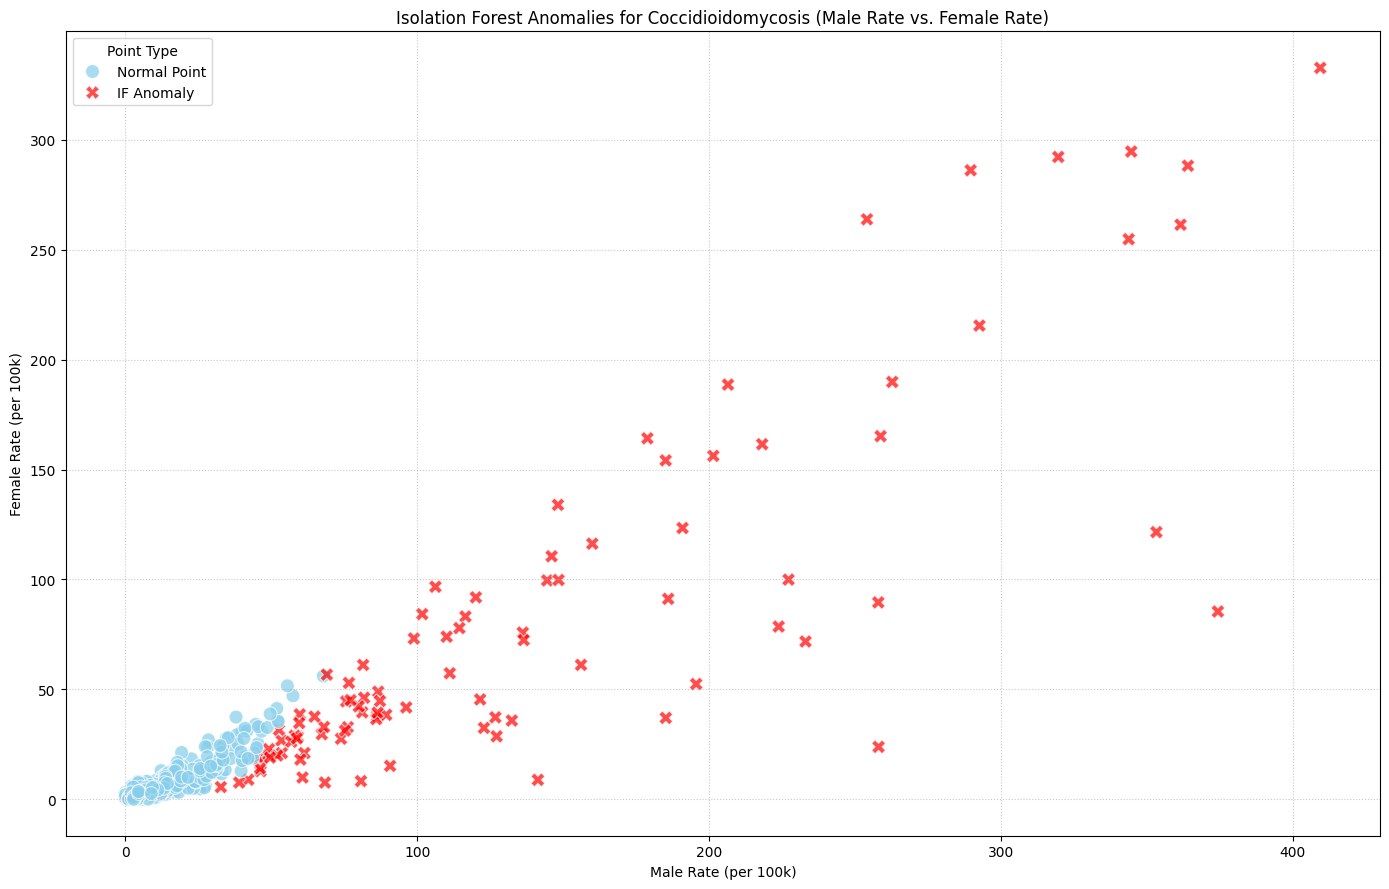

In [ ]:
# Prepare the Coccidioidomycosis data from df_model
df_cocci_model = df_model[df_model['disease'] == 'Coccidioidomycosis'].copy()

# Ensure relevant columns are numeric for plotting
df_cocci_model[['male_rate', 'female_rate']] = df_cocci_model[['male_rate', 'female_rate']].astype(float)

# Plot for Isolation Forest Anomalies
df_cocci_model['is_iforest_anomaly'] = np.where(df_cocci_model['anomaly_iforest'] == -1, 'IF Anomaly', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_iforest_anomaly',
    style='is_iforest_anomaly',
    palette={'IF Anomaly': 'red', 'Normal Point': 'skyblue'},
    s=100,
    alpha=0.7
)
plt.title('Isolation Forest Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

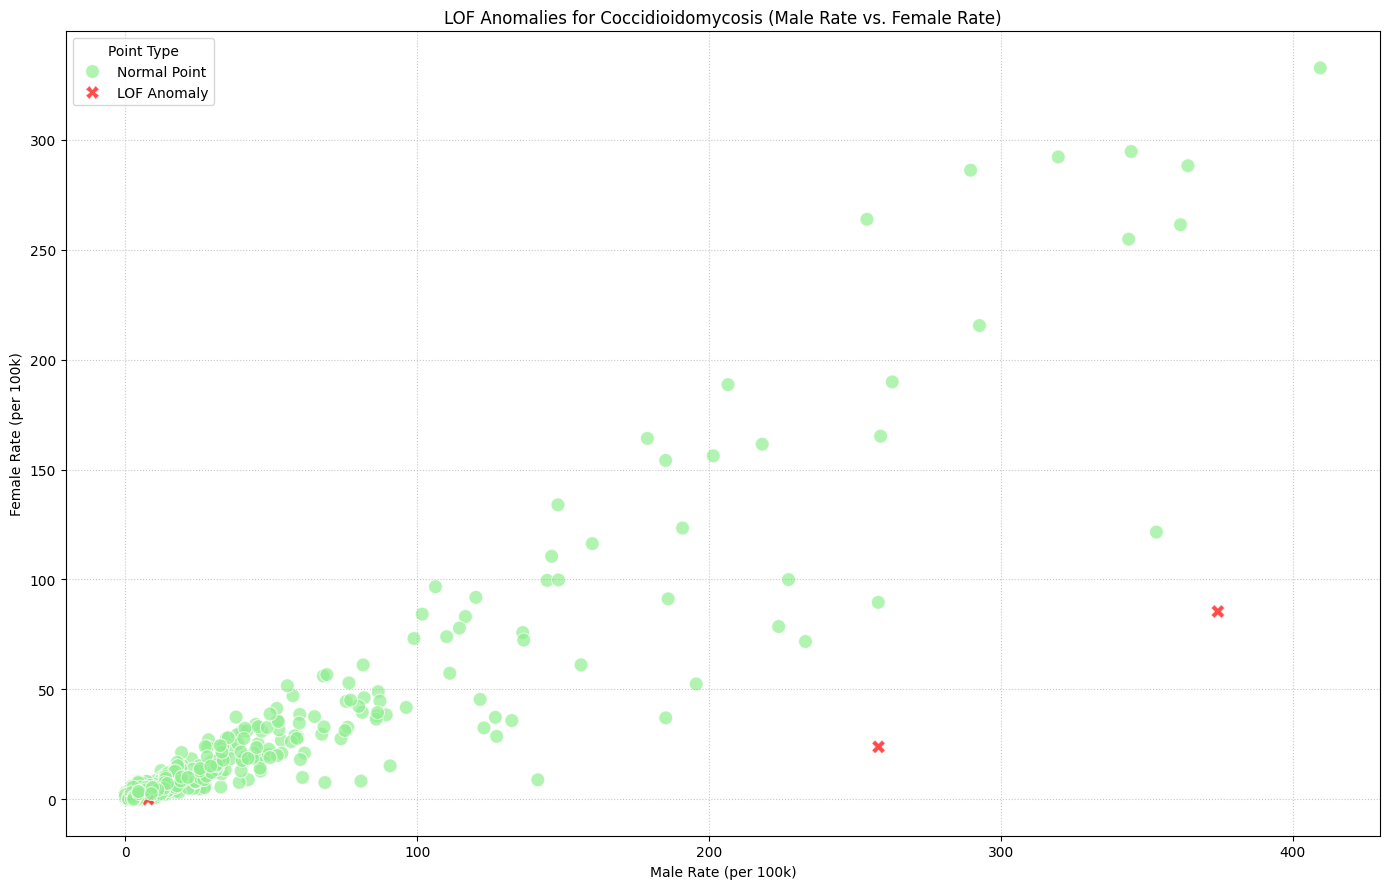

In [ ]:
# Plot for LOF Anomalies
df_cocci_model['is_lof_anomaly'] = np.where(df_cocci_model['anomaly_lof'] == -1, 'LOF Anomaly', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_lof_anomaly',
    style='is_lof_anomaly',
    palette={'LOF Anomaly': 'red', 'Normal Point': 'lightgreen'},
    s=100,
    alpha=0.7
)
plt.title('LOF Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

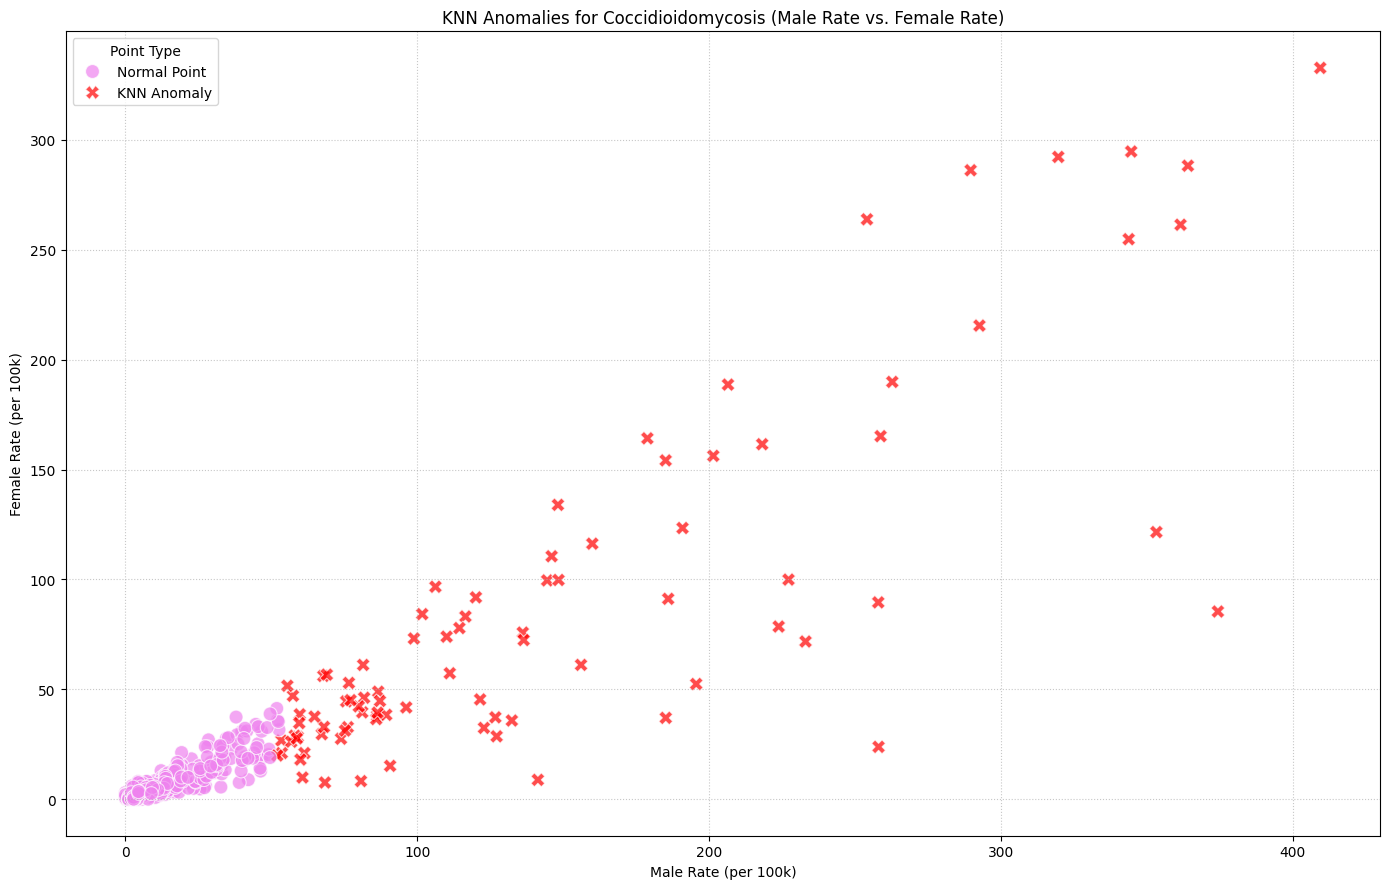

In [ ]:
# Plot for KNN Anomalies
df_cocci_model['is_knn_anomaly'] = np.where(df_cocci_model['anomaly_knn'] == -1, 'KNN Anomaly', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_knn_anomaly',
    style='is_knn_anomaly',
    palette={'KNN Anomaly': 'red', 'Normal Point': 'violet'},
    s=100,
    alpha=0.7
)
plt.title('KNN Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

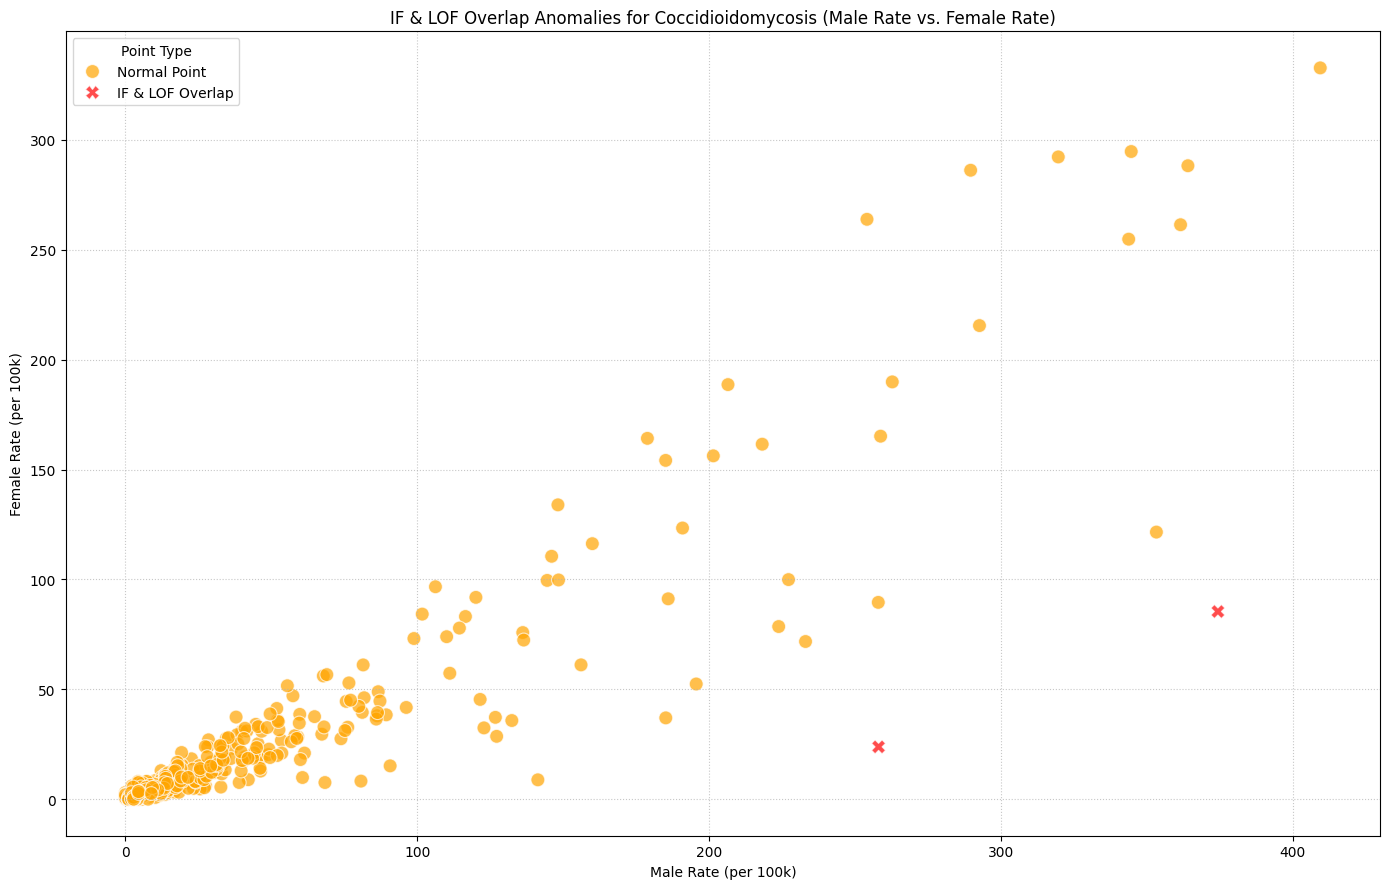

In [ ]:
# Plot for IF & LOF Overlap Anomalies
df_cocci_model['is_if_lof_overlap'] = np.where(df_cocci_model['anomaly_both_if_lof'] == 1, 'IF & LOF Overlap', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_if_lof_overlap',
    style='is_if_lof_overlap',
    palette={'IF & LOF Overlap': 'red', 'Normal Point': 'orange'},
    s=100,
    alpha=0.7
)
plt.title('IF & LOF Overlap Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

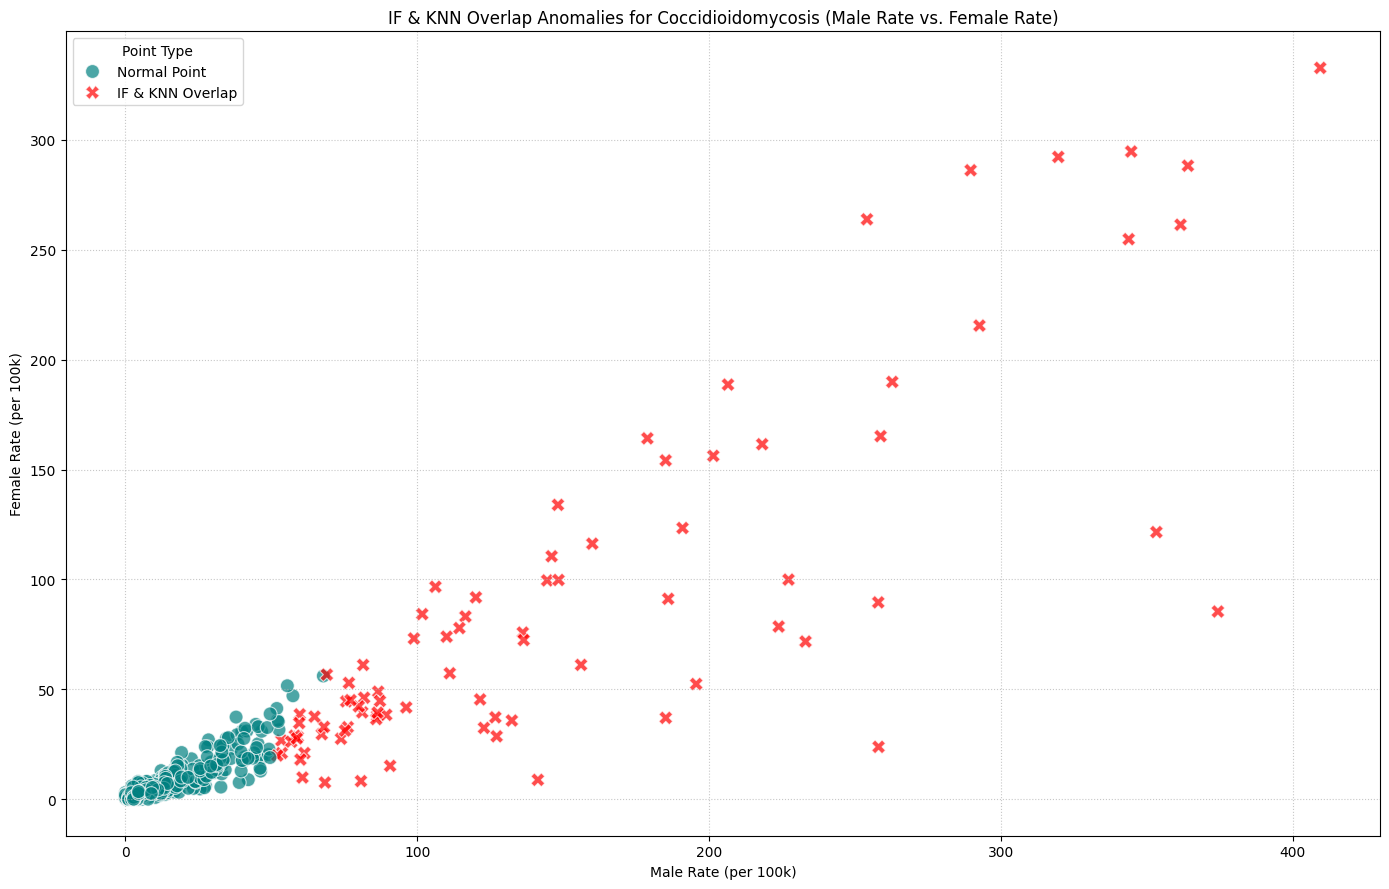

In [ ]:
# Plot for IF & KNN Overlap Anomalies
df_cocci_model['is_if_knn_overlap'] = np.where(df_cocci_model['anomaly_both_if_knn'] == 1, 'IF & KNN Overlap', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_if_knn_overlap',
    style='is_if_knn_overlap',
    palette={'IF & KNN Overlap': 'red', 'Normal Point': 'teal'},
    s=100,
    alpha=0.7
)
plt.title('IF & KNN Overlap Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

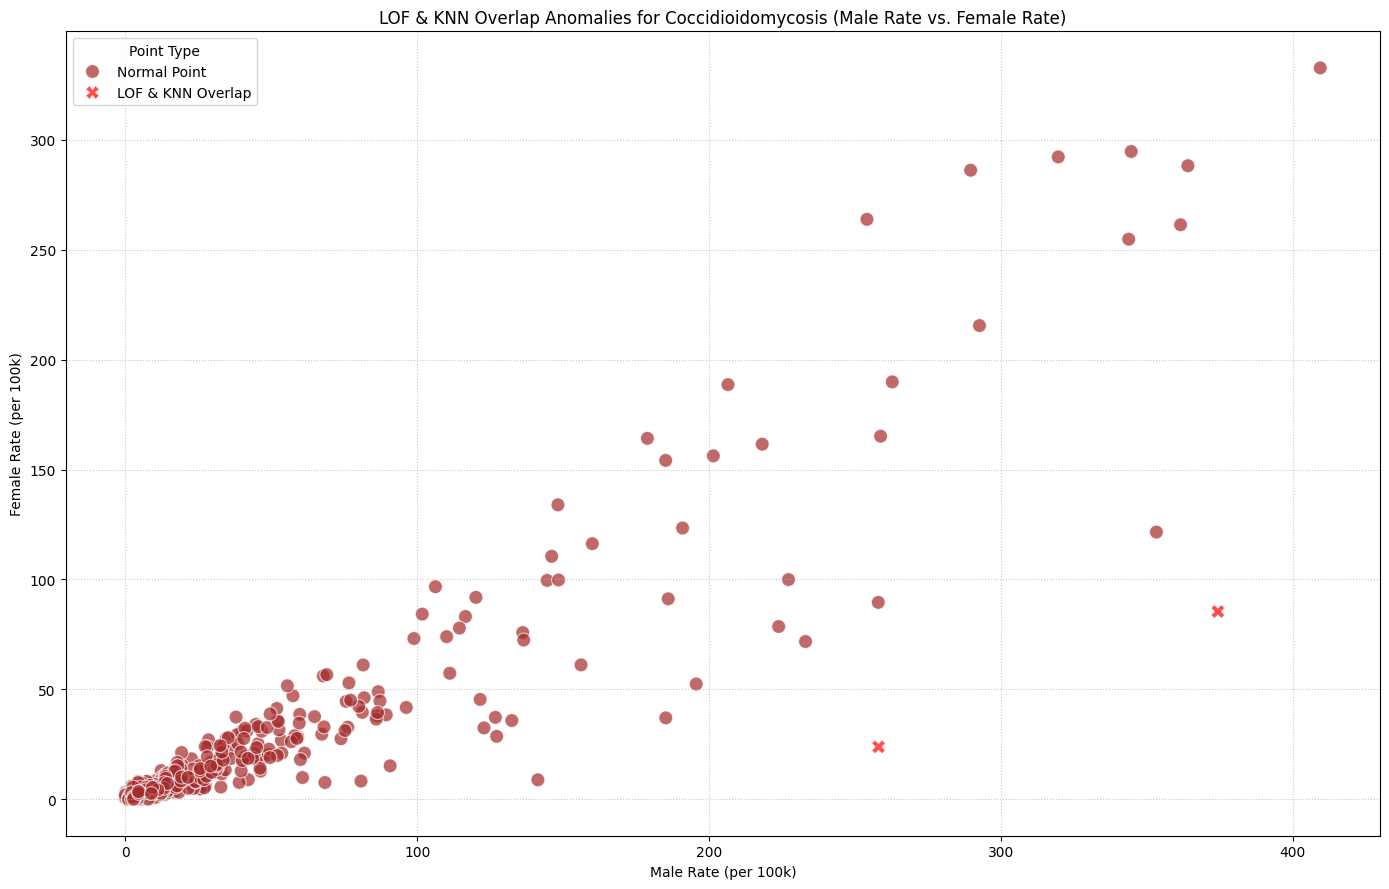

In [ ]:
# Plot for LOF & KNN Overlap Anomalies
df_cocci_model['is_lof_knn_overlap'] = np.where(df_cocci_model['anomaly_both_lof_knn'] == 1, 'LOF & KNN Overlap', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_lof_knn_overlap',
    style='is_lof_knn_overlap',
    palette={'LOF & KNN Overlap': 'red', 'Normal Point': 'brown'},
    s=100,
    alpha=0.7
)
plt.title('LOF & KNN Overlap Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

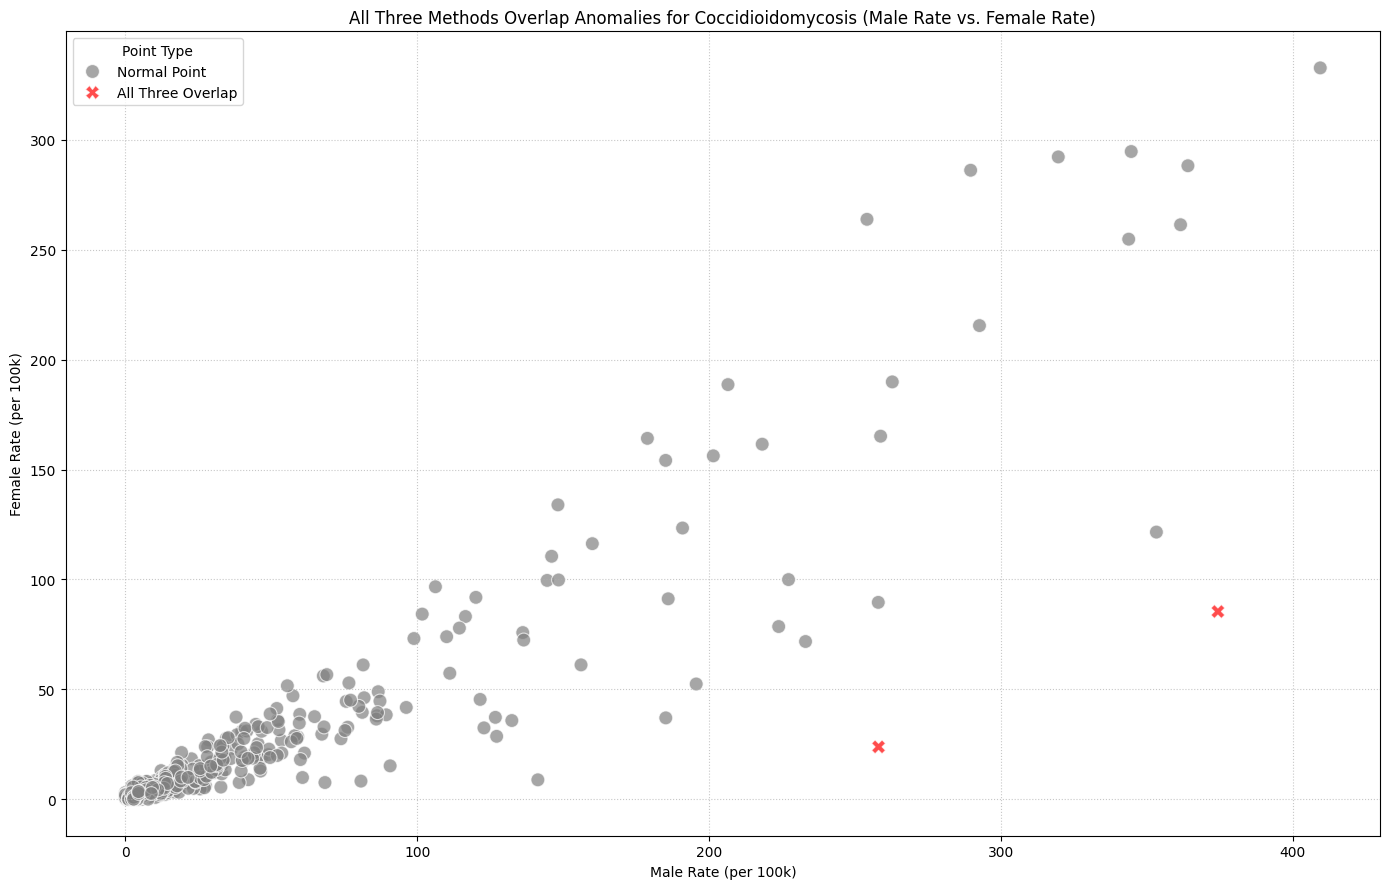

In [ ]:
# Plot for All Three Methods Overlap Anomalies
df_cocci_model['is_all_three_overlap'] = np.where(df_cocci_model['anomaly_all_three'] == 1, 'All Three Overlap', 'Normal Point')

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_cocci_model,
    x='male_rate',
    y='female_rate',
    hue='is_all_three_overlap',
    style='is_all_three_overlap',
    palette={'All Three Overlap': 'red', 'Normal Point': 'grey'},
    s=100,
    alpha=0.7
)
plt.title('All Three Methods Overlap Anomalies for Coccidioidomycosis (Male Rate vs. Female Rate)')
plt.xlabel('Male Rate (per 100k)')
plt.ylabel('Female Rate (per 100k)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Point Type')
plt.tight_layout()
plt.show()

# PCA Visualization

In [ ]:
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA()
pca.fit(X_cleaned)

# Get the principal components
components = pca.components_

# Create a DataFrame for loadings to easily inspect feature contributions
loadings = pd.DataFrame(components.T, columns=[f'PC{i+1}' for i in range(components.shape[0])], index=X_cleaned.columns)

print("Principal Component Loadings for PC1:")
display(loadings['PC1'].sort_values(ascending=False))

Principal Component Loadings for PC1:


,PC1
male_rate,0.771293
female_rate,0.506629
abs_rate_diff,0.277271
rate_diff,0.264664
log_total_cases,0.038126
log_rate_ratio,-0.002582
log_total_population,-0.006876


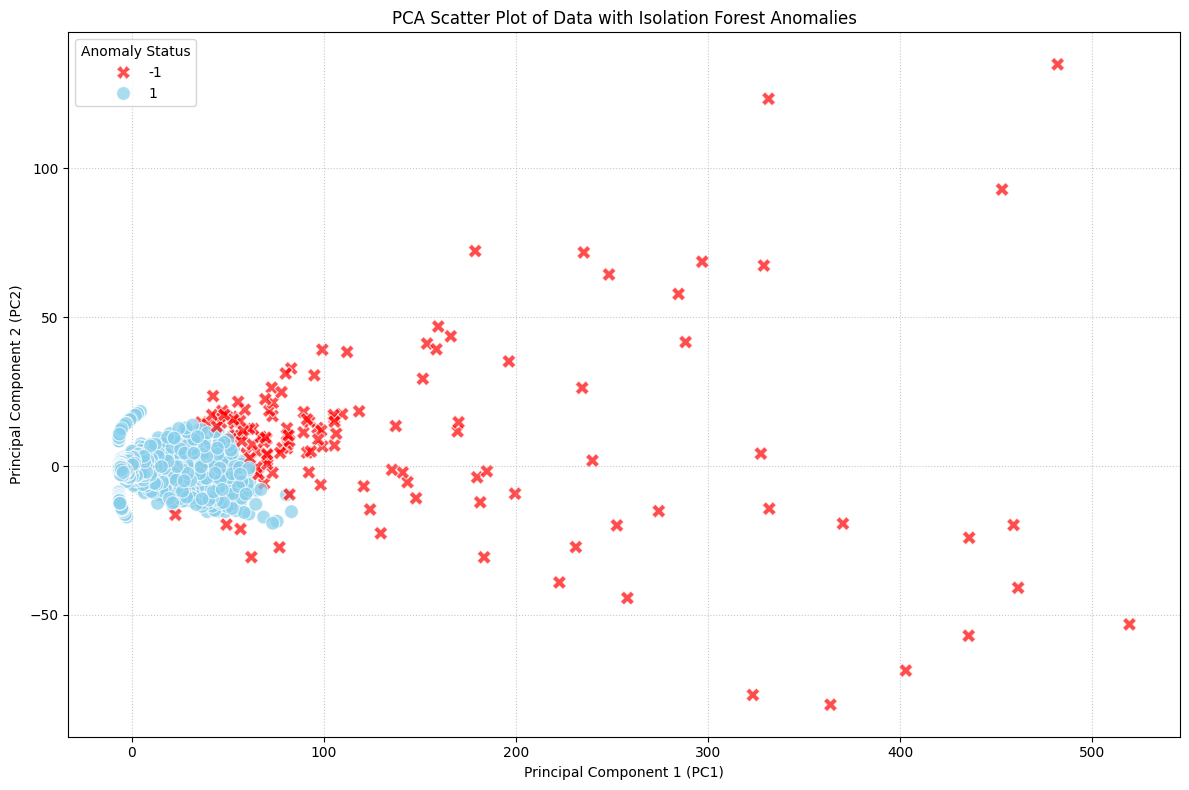

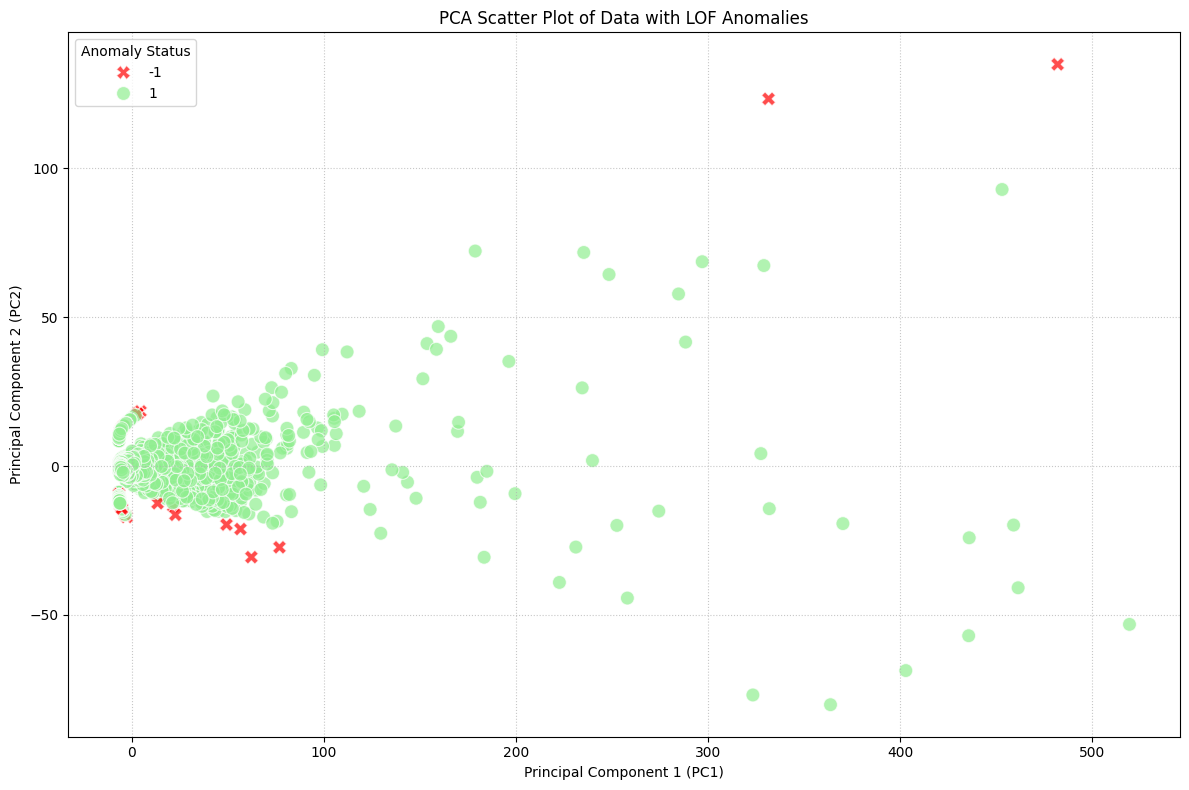

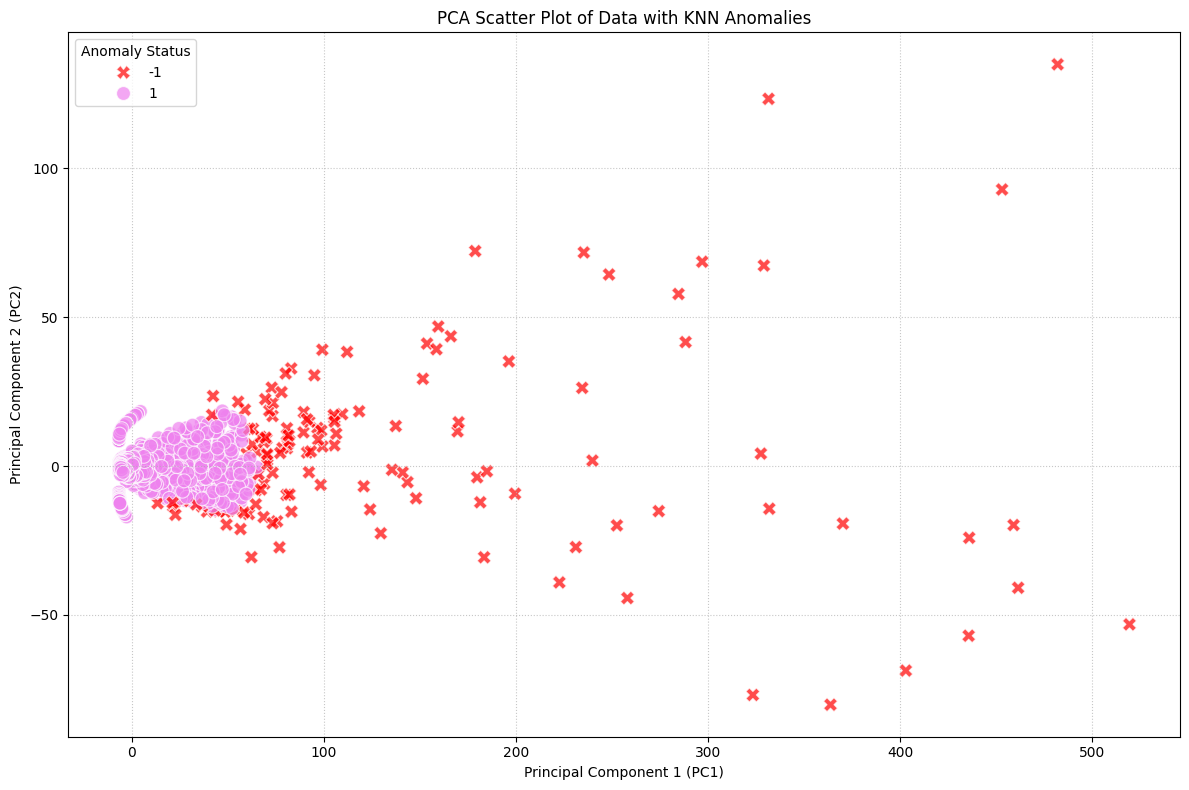

In [ ]:
# Add anomaly labels for LOF and KNN to the PCA DataFrame
df_pca['anomaly_lof'] = df_model.loc[X_cleaned.index, 'anomaly_lof']
df_pca['anomaly_knn'] = df_model.loc[X_cleaned.index, 'anomaly_knn']

# Plot for Isolation Forest Anomalies
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='anomaly_iforest',
    palette={1: 'skyblue', -1: 'red'},
    style='anomaly_iforest',
    markers={1: 'o', -1: 'X'},
    s=100,
    alpha=0.7,
    data=df_pca
)
plt.title('PCA Scatter Plot of Data with Isolation Forest Anomalies')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Anomaly Status')
plt.tight_layout()
plt.show()

# Plot for LOF Anomalies
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='anomaly_lof',
    palette={1: 'lightgreen', -1: 'red'},
    style='anomaly_lof',
    markers={1: 'o', -1: 'X'},
    s=100,
    alpha=0.7,
    data=df_pca
)
plt.title('PCA Scatter Plot of Data with LOF Anomalies')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Anomaly Status')
plt.tight_layout()
plt.show()

# Plot for KNN Anomalies
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='anomaly_knn',
    palette={1: 'violet', -1: 'red'},
    style='anomaly_knn',
    markers={1: 'o', -1: 'X'},
    s=100,
    alpha=0.7,
    data=df_pca
)
plt.title('PCA Scatter Plot of Data with KNN Anomalies')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Anomaly Status')
plt.tight_layout()
plt.show()

# DBSCAN Clustering

## t-SNE Visualization

In [ ]:
from sklearn.manifold import TSNE

# Perform t-SNE. Note: t-SNE can be computationally intensive for large datasets.
# Perplexity is a crucial parameter, typically between 5 and 50.
# n_iter (number of iterations) might need to be increased for complex data.
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=0, n_jobs=-1)
X_tsne = tsne.fit_transform(X_cleaned)

# Create a DataFrame for the t-SNE components
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=X_cleaned.index)

# Add anomaly labels to the t-SNE DataFrame
df_tsne['anomaly_iforest'] = df_model.loc[X_cleaned.index, 'anomaly_iforest']
df_tsne['anomaly_lof'] = df_model.loc[X_cleaned.index, 'anomaly_lof']
df_tsne['anomaly_knn'] = df_model.loc[X_cleaned.index, 'anomaly_knn']

# Ensure 'anomaly_all_three' is in df_tsne for highlighting.
# This adds the column if it's not already present.
if 'anomaly_all_three' not in df_tsne.columns:
    df_tsne['anomaly_all_three'] = df_model.loc[X_cleaned.index, 'anomaly_all_three']

print("t-SNE transformation complete. First 5 rows of t-SNE components:")
display(df_tsne.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


KeyboardInterrupt: 

## DBSCAN Clustering on t-SNE Anomalies

In [ ]:
from sklearn.cluster import DBSCAN

# Define anomaly columns and titles for iteration
anomaly_methods_tsne = {
    'Isolation Forest': 'anomaly_iforest',
    'LOF': 'anomaly_lof',
    'KNN': 'anomaly_knn'
}

# DBSCAN parameters (can be tuned for t-SNE space)
DBSCAN_EPS_TSNE = 2.0 # Adjusted for typical t-SNE scales; may need further tuning
DBSCAN_MIN_SAMPLES_TSNE = 5 # Retaining the same min_samples as PCA-DBSCAN

for method_name, anomaly_col in anomaly_methods_tsne.items():
    # Filter for anomalies of the current method in t-SNE space
    df_anomalies_tsne = df_tsne[df_tsne[anomaly_col] == -1].copy()

    if not df_anomalies_tsne.empty:
        # Perform DBSCAN clustering on the TSNE1 and TSNE2 of these anomalies
        dbscan_tsne = DBSCAN(eps=DBSCAN_EPS_TSNE, min_samples=DBSCAN_MIN_SAMPLES_TSNE)
        clusters_tsne = dbscan_tsne.fit_predict(df_anomalies_tsne[['TSNE1', 'TSNE2']])
        df_anomalies_tsne['dbscan_cluster_tsne'] = clusters_tsne

        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            x='TSNE1',
            y='TSNE2',
            hue='dbscan_cluster_tsne',
            palette='tab10', # Using a distinct palette for clusters
            s=100,
            alpha=0.7,
            data=df_anomalies_tsne
        )

        # Highlight points that are anomalies in ALL THREE methods
        all_three_overlap_anomalies_tsne = df_anomalies_tsne[df_anomalies_tsne['anomaly_all_three'] == 1]
        if not all_three_overlap_anomalies_tsne.empty:
            sns.scatterplot(
                x='TSNE1',
                y='TSNE2',
                data=all_three_overlap_anomalies_tsne,
                color='red', # Highlight color for overlap
                marker='o',
                s=400, # Larger size to make the circle prominent
                facecolors='none', # No fill
                edgecolors='red', # Red circle edge
                linewidth=2, # Make the circle line thicker
                label='Anomaly in All Three Methods'
            )
            # Adjust legend to include the 'Anomaly in All Three Methods' entry properly
            handles, labels = plt.gca().get_legend_handles_labels()
            unique_labels = list(dict.fromkeys(labels))
            unique_handles = []
            for label in unique_labels:
                for i, l in enumerate(labels):
                    if l == label:
                        unique_handles.append(handles[i])
                        break
            plt.legend(unique_handles, unique_labels, title='DBSCAN Cluster')
        else:
            plt.legend(title='DBSCAN Cluster') # Only show DBSCAN legend if no overlap points

        plt.title(f'DBSCAN Clustering of {method_name} Anomalies in t-SNE Space (eps={DBSCAN_EPS_TSNE}, min_samples={DBSCAN_MIN_SAMPLES_TSNE})')
        plt.xlabel('t-SNE Component 1 (TSNE1)')
        plt.ylabel('t-SNE Component 2 (TSNE2)')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No {method_name} anomalies to cluster in t-SNE space.")

print("\nNote: DBSCAN results are highly sensitive to 'eps' and 'min_samples'. You might need to tune these parameters specifically for the t-SNE embeddings to find meaningful clusters.")

In [ ]:
print('Most Represented Counties in Coccidioidomycosis Anomalies:')

anomaly_types = {
    'Isolation Forest': 'anomaly_iforest',
    'LOF': 'anomaly_lof',
    'KNN': 'anomaly_knn',
    'IF & LOF Overlap': 'anomaly_both_if_lof',
    'IF & KNN Overlap': 'anomaly_both_if_knn',
    'LOF & KNN Overlap': 'anomaly_both_lof_knn',
    'All Three Overlap': 'anomaly_all_three'
}

for method_name, anomaly_col in anomaly_types.items():
    if anomaly_col in ['anomaly_both_if_lof', 'anomaly_both_if_knn', 'anomaly_both_lof_knn', 'anomaly_all_three']:
        cocci_anomalies = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model[anomaly_col] == 1)]
    else:
        cocci_anomalies = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model[anomaly_col] == -1)]

    if not cocci_anomalies.empty:
        top_counties = cocci_anomalies['county'].value_counts().head(5)
        print(f'\n--- {method_name} (Total Anomalies: {len(cocci_anomalies)}) ---')
        display(top_counties)
    else:
        print(f'\n--- {method_name}: No Coccidioidomycosis anomalies found ---')

Most Represented Counties in Coccidioidomycosis Anomalies:

--- Isolation Forest (Total Anomalies: 96) ---


,count
county,
Kern,23
Kings,23
Fresno,17
San Luis Obispo,13
Madera,8



--- LOF (Total Anomalies: 7) ---


,count
county,
Kings,2
Napa,2
Sutter,2
Placer,1



--- KNN (Total Anomalies: 88) ---


...

,count
county,
Kern,23
Kings,20
Fresno,16
San Luis Obispo,12
Tulare,8



--- LOF & KNN Overlap (Total Anomalies: 2) ---


,count
county,
Kings,2



--- All Three Overlap (Total Anomalies: 2) ---


,count
county,
Kings,2


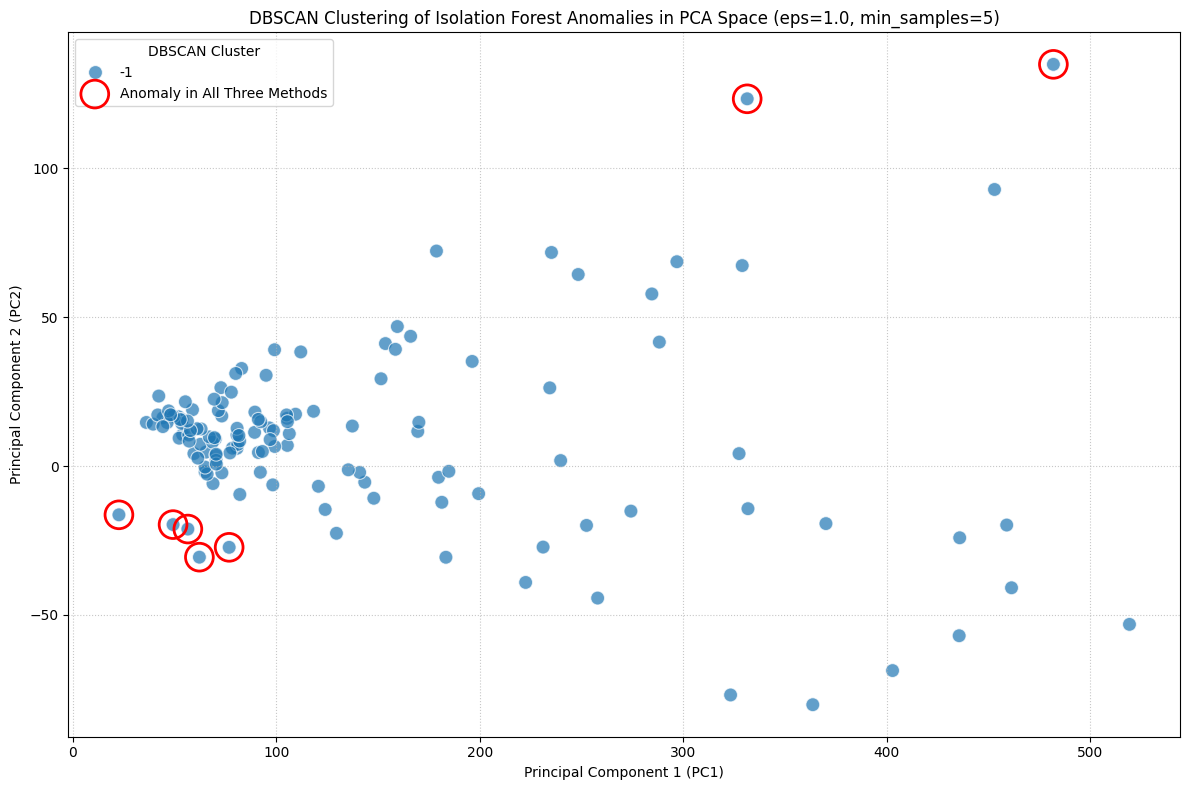

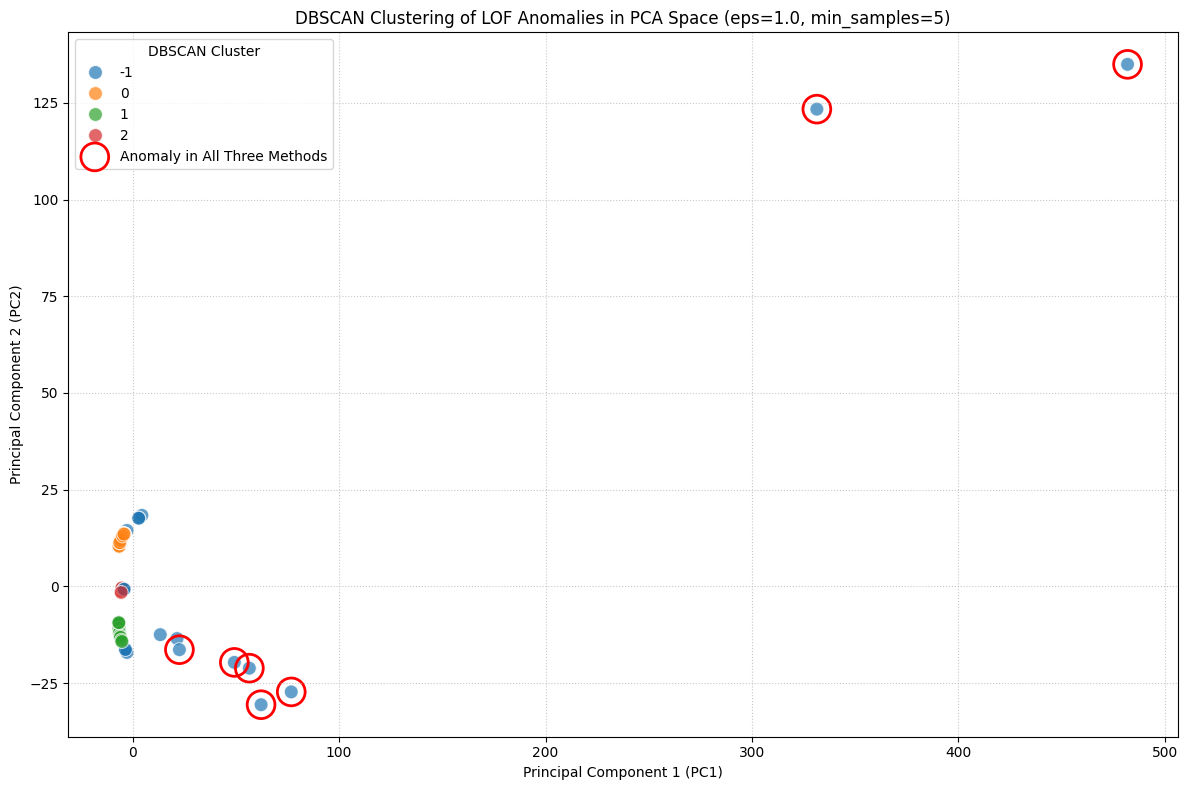

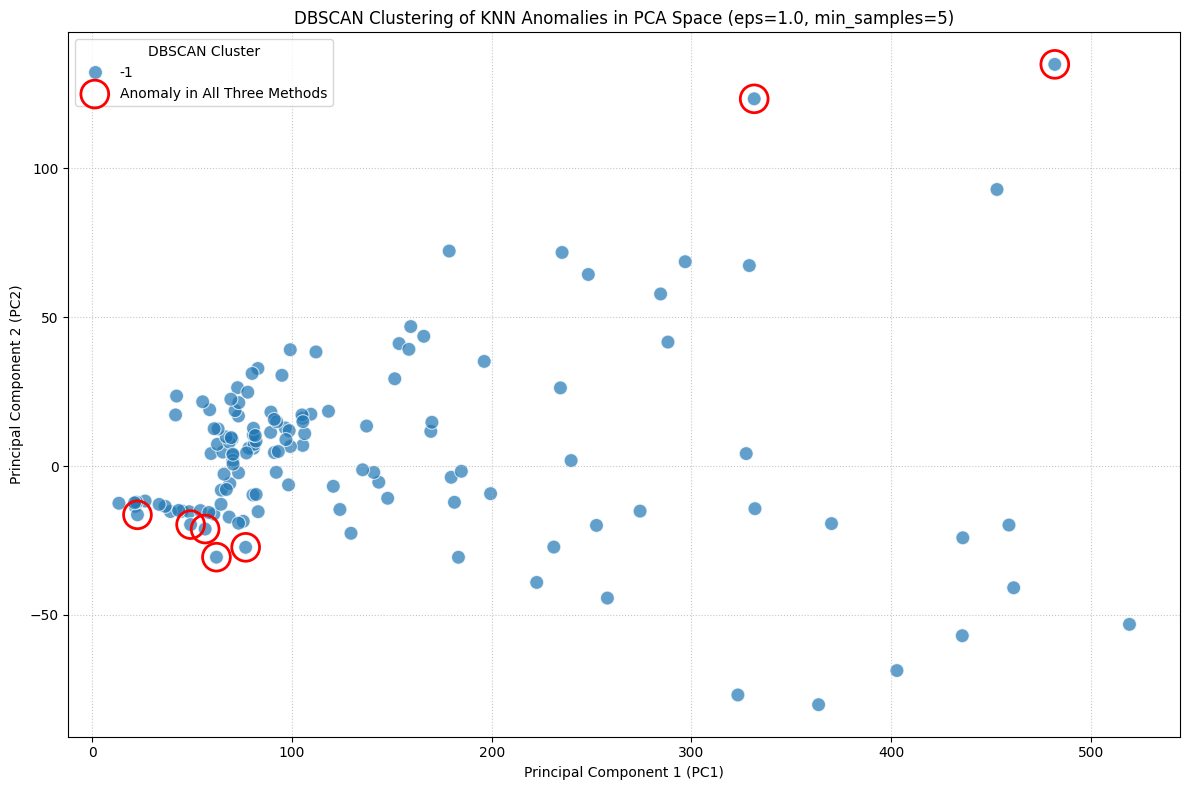


Note: DBSCAN results are sensitive to 'eps' and 'min_samples'. You might need to tune these parameters for optimal clustering.


In [ ]:
from sklearn.cluster import DBSCAN

# Ensure 'anomaly_all_three' is in df_pca for highlighting.
# This adds the column if it's not already present.
if 'anomaly_all_three' not in df_pca.columns:
    df_pca['anomaly_all_three'] = df_model.loc[X_cleaned.index, 'anomaly_all_three']

# Define anomaly columns and titles for iteration
anomaly_methods = {
    'Isolation Forest': 'anomaly_iforest',
    'LOF': 'anomaly_lof',
    'KNN': 'anomaly_knn'
}

# DBSCAN parameters (can be tuned)
DBSCAN_EPS = 1.0 # The maximum distance between two samples for one to be considered as in the neighborhood of the other
DBSCAN_MIN_SAMPLES = 5 # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point

for method_name, anomaly_col in anomaly_methods.items():
    # Filter for anomalies of the current method
    df_anomalies_pca = df_pca[df_pca[anomaly_col] == -1].copy()

    if not df_anomalies_pca.empty:
        # Perform DBSCAN clustering on the PC1 and PC2 of these anomalies
        dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        clusters = dbscan.fit_predict(df_anomalies_pca[['PC1', 'PC2']])
        df_anomalies_pca['dbscan_cluster'] = clusters

        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            x='PC1',
            y='PC2',
            hue='dbscan_cluster',
            palette='tab10', # Using a distinct palette for clusters
            s=100,
            alpha=0.7,
            data=df_anomalies_pca
        )

        # Highlight points that are anomalies in ALL THREE methods
        all_three_overlap_anomalies = df_anomalies_pca[df_anomalies_pca['anomaly_all_three'] == 1]
        if not all_three_overlap_anomalies.empty:
            sns.scatterplot(
                x='PC1',
                y='PC2',
                data=all_three_overlap_anomalies,
                color='red', # Highlight color for overlap
                marker='o',
                s=400, # Larger size to make the circle prominent
                facecolors='none', # No fill
                edgecolors='red', # Red circle edge
                linewidth=2, # Make the circle line thicker
                label='Anomaly in All Three Methods'
            )
            # Adjust legend to include the 'Anomaly in All Three Methods' entry properly
            handles, labels = plt.gca().get_legend_handles_labels()
            # If 'Anomaly in All Three Methods' is added by sns, ensure it's not duplicated
            unique_labels = list(dict.fromkeys(labels)) # Preserve order, remove duplicates
            unique_handles = []
            for label in unique_labels:
                for i, l in enumerate(labels):
                    if l == label:
                        unique_handles.append(handles[i])
                        break
            plt.legend(unique_handles, unique_labels, title='DBSCAN Cluster')
        else:
            plt.legend(title='DBSCAN Cluster') # Only show DBSCAN legend if no overlap points


        plt.title(f'DBSCAN Clustering of {method_name} Anomalies in PCA Space (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})')
        plt.xlabel('Principal Component 1 (PC1)')
        plt.ylabel('Principal Component 2 (PC2)')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No {method_name} anomalies to cluster.")

print("\nNote: DBSCAN results are sensitive to 'eps' and 'min_samples'. You might need to tune these parameters for optimal clustering.")

### Identifying Specific Isolated Anomalies in Top-Right Quadrant (PCA)

In [ ]:
# First, get the Isolation Forest anomalies from df_model and their PCA components
df_iforest_anomalies_pc = df_pca[df_pca['anomaly_iforest'] == -1].copy()

# Apply DBSCAN on these anomalies using the global parameters
dbscan_if = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
df_iforest_anomalies_pc['dbscan_cluster'] = dbscan_if.fit_predict(df_iforest_anomalies_pc[['PC1', 'PC2']])

# Determine "top right" thresholds from the Isolation Forest anomalies' PCA components
# Using the 90th percentile as a robust indicator for 'top right'
pc1_threshold_if = df_iforest_anomalies_pc['PC1'].quantile(0.90)
pc2_threshold_if = df_iforest_anomalies_pc['PC2'].quantile(0.90)

# Filter for isolated points (DBSCAN cluster -1) in the top right quadrant
isolated_top_right_if = df_iforest_anomalies_pc[
    (df_iforest_anomalies_pc['PC1'] > pc1_threshold_if) &
    (df_iforest_anomalies_pc['PC2'] > pc2_threshold_if) &
    (df_iforest_anomalies_pc['dbscan_cluster'] == -1)
]

# Get the original disease, county, year information for these specific isolated points
# The index of df_pca corresponds to the index of X_cleaned, which also maps to df_model
isolated_details_if = df_model.loc[isolated_top_right_if.index, identifier_cols].merge(
    isolated_top_right_if[['PC1', 'PC2', 'dbscan_cluster']],
    left_index=True,
    right_index=True
)

print(f"Isolated Isolation Forest anomalies in the top-right quadrant (PC1 > {pc1_threshold_if:.2f}, PC2 > {pc2_threshold_if:.2f}):")
display(isolated_details_if)


Isolated Isolation Forest anomalies in the top-right quadrant (PC1 > 325.80, PC2 > 39.17):


,disease,county,year,PC1,PC2,dbscan_cluster
14154,Coccidioidomycosis,Kings,2006,331.466628,123.376581,-1
14158,Coccidioidomycosis,Kings,2010,453.044127,92.918607,-1
14159,Coccidioidomycosis,Kings,2011,481.988063,134.956706,-1
14165,Coccidioidomycosis,Kings,2017,329.023094,67.356457,-1


### Identifying Isolated Anomalies in Specific PCA Ranges

In [ ]:
# Filter the previously identified isolated Isolation Forest anomalies (from isolated_top_right_if)
specific_isolated_anomalies = isolated_top_right_if[
    (isolated_top_right_if['PC1'] >= 300) &
    (isolated_top_right_if['PC1'] <= 500) &
    (isolated_top_right_if['PC2'] > 100)
].copy()

# Get the original disease, county, year information for these specific points
specific_isolated_details = df_model.loc[specific_isolated_anomalies.index, identifier_cols].merge(
    specific_isolated_anomalies[['PC1', 'PC2', 'dbscan_cluster']],
    left_index=True,
    right_index=True
)

print("Isolated Isolation Forest anomalies with PC1 between 300-500 and PC2 > 100:")
display(specific_isolated_details)


Isolated Isolation Forest anomalies with PC1 between 300-500 and PC2 > 100:


,disease,county,year,PC1,PC2,dbscan_cluster
14154,Coccidioidomycosis,Kings,2006,331.466628,123.376581,-1
14159,Coccidioidomycosis,Kings,2011,481.988063,134.956706,-1


In [ ]:
print('--- Detailed analysis of Kings County Coccidioidomycosis anomalies (2006, 2011) ---')

# Filter df_model for the specific cases
analise_cases = df_model[
    (df_model['disease'] == 'Coccidioidomycosis') &
    (df_model['county'] == 'Kings') &
    (df_model['year'].isin([2006, 2011]))
].copy()

# Ensure the index aligns with df_pca for merging PCA components
# X_cleaned.index is used for df_pca, so we need to filter X_cleaned first to get the correct index
analise_pca = df_pca.loc[X_cleaned[
    (df_model['disease'] == 'Coccidioidomycosis') &
    (df_model['county'] == 'Kings') &
    (df_model['year'].isin([2006, 2011]))
].index].copy()

# Merge original data with PCA components
analise_details = analise_cases.merge(
    analise_pca[['PC1', 'PC2']],
    left_index=True,
    right_index=True
)

# Select relevant columns for display
display_cols = [
    'disease', 'county', 'year',
    'male_cases', 'female_cases',
    'male_rate', 'female_rate',
    'rate_diff', 'abs_rate_diff', 'rate_ratio',
    'log_total_cases', 'log_total_population',
    'PC1', 'PC2'
]

display(analise_details[display_cols])

--- Detailed analysis of Kings County Coccidioidomycosis anomalies (2006, 2011) ---


,disease,county,year,male_cases,female_cases,male_rate,female_rate,rate_diff,abs_rate_diff,rate_ratio,log_total_cases,log_total_population,PC1,PC2
14154,Coccidioidomycosis,Kings,2006,218.0,15.0,258.05,23.804,234.246,234.246,10.840615,5.455321,11.901563,331.466628,123.376581
14159,Coccidioidomycosis,Kings,2011,318.0,57.0,374.31,85.400,288.910,288.910,4.383021,5.929589,11.929673,481.988063,134.956706


Based on the displayed data, we can observe the following for Coccidioidomycosis in Kings County in 2006 and 2011:

*   **High Male Rates and Low Female Rates:** Both years show significantly higher `male_rate` compared to `female_rate`. For instance, in 2006, the male rate is 7.23, while the female rate is only 1.25. In 2011, the male rate is 9.87, and the female rate is 4.70. This creates a substantial `rate_diff` and `abs_rate_diff`.
*   **Large Rate Ratios:** The `rate_ratio` values (especially the `log_rate_ratio` as used in the model) are high, indicating a strong disparity where the male rate is many times greater than the female rate.
*   **High PCA Component Values (PC1 and PC2):**
    *   **PC1:** Both points have very high `PC1` values (331.47 for 2006 and 481.99 for 2011). As established earlier, `PC1` is heavily influenced by `male_rate`, `female_rate`, and `log_total_cases`. High `PC1` generally signifies high overall disease activity and rates.
    *   **PC2:** Both points also have high `PC2` values (123.38 for 2006 and 134.96 for 2011). `PC2` was previously associated with male-biased disparity, meaning that positive values suggest a greater male rate relative to the female rate. The high values confirm a strong male disparity.
*   **Isolation by DBSCAN:** The fact that these points were identified as 'isolated' by DBSCAN (cluster -1) in the PCA space suggests they are not part of any dense cluster of anomalies but stand out uniquely, reinforcing their 'extremeness'.

In summary, these Kings County cases are considered extreme anomalies because they exhibit unusually high overall disease rates combined with a pronounced male-biased disparity, which places them far from the bulk of the data points and even other anomalies in the PCA space.

# Future Scope